In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('rainfall.csv')
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Address              2191 non-null   object 
 1   Date time            2191 non-null   object 
 2   Minimum Temperature  2191 non-null   float64
 3   Maximum Temperature  2191 non-null   float64
 4   Temperature          2191 non-null   float64
 5   Dew Point            2191 non-null   float64
 6   Relative Humidity    2191 non-null   float64
 7   Heat Index           1851 non-null   float64
 8   Wind Speed           2191 non-null   float64
 9   Wind Gust            91 non-null     float64
 10  Wind Direction       2191 non-null   float64
 11  Wind Chill           13 non-null     float64
 12  Precipitation        2191 non-null   float64
 13  Precipitation Cover  2191 non-null   float64
 14  Snow Depth           1826 non-null   float64
 15  Visibility           2191 non-null   f

,Minimum Temperature,Maximum Temperature,Temperature,Dew Point,Relative Humidity,Heat Index,Wind Speed,Wind Gust,Wind Direction,Wind Chill,Precipitation,Precipitation Cover,Snow Depth,Visibility,Cloud Cover,Sea Level Pressure,Latitude,Longitude,Info
count,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,1851.000000,2191.000000,91.000000,2191.000000,13.000000,2191.000000,2191.000000,1826.0,2191.000000,2191.000000,2190.000000,2.191000e+03,2191.0000,0.0
mean,22.736604,31.397490,26.677088,21.713555,76.298530,40.416856,11.272980,29.865934,154.037335,8.730769,4.492268,4.169220,0.0,2.022821,41.431858,1007.768219,2.257050e+01,88.3713,NaN
std,5.228905,4.135988,4.415869,5.510843,10.249919,7.713052,6.163396,6.032766,52.448529,0.712255,13.268362,6.330994,0.0,0.334513,27.920853,5.949442,3.553525e-15,0.0000,NaN
min,9.000000,18.000000,14.200000,5.800000,41.150000,26.300000,3.400000,20.800000,20.950000,7.600000,0.000000,0.000000,0.0,0.700000,0.000000,988.400000,2.257050e+01,88.3713,NaN
25%,19.000000,29.000000,23.600000,17.100000,69.075000,33.700000,8.100000,25.300000,115.960000,7.900000,0.000000,0.000000,0.0,1.800000,14.900000,1003.000000,2.257050e+01,88.3713,NaN
50%,25.000000,32.000000,28.300000,24.000000,77.080000,41.900000,10.300000,28.900000,156.130000,8.800000,0.000000,0.000000,0.0,2.100000,45.100000,1007.900000,2.257050e+01,88.3713,NaN
75%,27.000000,34.600000,30.000000,26.300000,84.220000,46.100000,13.900000,34.400000,191.020000,9.100000,1.675000,8.330000,0.0,2.300000,63.600000,1012.800000,2.257050e+01,88.3713,NaN
max,30.500000,41.000000,34.800000,30.100000,97.230000,61.200000,123.300000,55.300000,331.380000,9.600000,232.770000,34.780000,0.0,3.200000,100.000000,1019.700000,2.257050e+01,88.3713,NaN


In [5]:
df.isnull().sum()

Address                   0
Date time                 0
Minimum Temperature       0
Maximum Temperature       0
Temperature               0
Dew Point                 0
Relative Humidity         0
Heat Index              340
Wind Speed                0
Wind Gust              2100
Wind Direction            0
Wind Chill             2178
Precipitation             0
Precipitation Cover       0
Snow Depth              365
Visibility                0
Cloud Cover               0
Sea Level Pressure        1
Weather Type              1
Latitude                  0
Longitude                 0
Resolved Address          0
Name                      0
Info                   2191
Conditions                0
dtype: int64

In [4]:
#target variable creation
def rain_labeler(cond):
    cond = str(cond).lower()
    if 'rain' in cond or 'drizzle' in cond or 'thunderstorm' in cond:
        return 1
    return 0

df['RainLabel'] = df['Conditions'].apply(rain_labeler)
df['RainLabel'].value_counts()


RainLabel
0    1308
1     883
Name: count, dtype: int64

In [5]:
#drop unnecessary columns
drop_cols = ['Address', 'Date time', 'Precipitation', 'Precipitation Cover',
             'Snow Depth', 'Resolved Address', 'Name', 'Info', 
             'Conditions', 'Weather Type', 'Latitude', 'Longitude']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df.head()

,Minimum Temperature,Maximum Temperature,Temperature,Dew Point,Relative Humidity,Heat Index,Wind Speed,Wind Gust,Wind Direction,Wind Chill,Visibility,Cloud Cover,Sea Level Pressure,RainLabel
0,14.0,25.3,19.9,16.5,82.47,NaN,5.8,NaN,78.33,NaN,1.2,4.9,1015.9,0
1,16.0,26.0,20.6,16.0,76.76,NaN,8.1,NaN,148.54,NaN,1.4,0.3,1015.6,0
2,16.0,27.0,21.1,15.6,73.12,27.3,9.2,NaN,244.92,NaN,1.6,10.7,1014.7,0
3,16.0,25.0,19.9,14.5,72.57,NaN,8.1,NaN,244.38,NaN,1.8,2.3,1014.6,0
4,15.0,25.6,19.6,13.7,71.88,NaN,8.1,NaN,231.58,NaN,1.9,0.0,1013.7,0


In [6]:
# Duplicate check
df.duplicated().sum()

np.int64(0)

In [7]:
df["Heat Index"].unique()


array([ nan, 27.3, 26.8, 26.5, 26.7, 26.3, 27.6, 29.2, 28.3, 27.5, 27.1,
       28.4, 29. , 28.8, 27.2, 28.1, 28.7, 29.5, 30. , 30.9, 31.9, 34.6,
       35.7, 35. , 29.3, 30.4, 30.1, 30.5, 34.1, 34. , 32.3, 32. , 36.5,
       33.7, 29.1, 31.5, 29.7, 32.4, 36.8, 30.6, 34.3, 35.1, 39. , 40.4,
       38.4, 40.6, 39.3, 39.8, 43.5, 42. , 40.9, 43.3, 39.1, 41.1, 36.9,
       38.9, 39.5, 43.2, 41.9, 41.4, 45.4, 44.8, 46.1, 44. , 45.1, 46.3,
       44.7, 39.7, 43.8, 46. , 44.9, 42.8, 42.7, 48. , 48.3, 41.6, 50.1,
       46.7, 44.4, 49. , 48.6, 50.9, 45. , 43.6, 41.5, 49.5, 50.2, 47.2,
       49.9, 52.5, 51. , 43.9, 42.4, 45.3, 42.3, 42.9, 47. , 48.1, 48.5,
       49.7, 34.5, 45.8, 42.1, 44.1, 47.3, 44.6, 41.7, 38.8, 37.1, 32.7,
       48.7, 40.7, 39.2, 42.2, 41.3, 40.2, 37.4, 43. , 44.3, 35.6, 40.3,
       37.3, 37.7, 33. , 32.5, 33.4, 30.8, 31.4, 32.9, 35.4, 31. , 29.9,
       33.6, 35.5, 27.9, 27. , 26.9, 28.2, 29.8, 26.4, 28.6, 30.3, 29.6,
       27.8, 27.4, 28. , 31.3, 35.2, 36.3, 34.2, 34

In [8]:
df["Sea Level Pressure"].unique()

array([1015.9, 1015.6, 1014.7, 1014.6, 1013.7, 1013.9, 1012.5, 1012.3,
       1012.1, 1013. , 1013.6, 1014.1, 1015.2, 1016.7, 1016.8, 1015.8,
       1015.7, 1018.4, 1018.1, 1017.6, 1018.3, 1017.3, 1017.8, 1017.9,
       1015. , 1014.5, 1014. , 1017.5, 1016.4, 1013.2, 1011.8, 1013.1,
       1012.8, 1015.4, 1018.9, 1016.5, 1015.5, 1012.4, 1008. , 1007.9,
       1009.2, 1011.7, 1013.3, 1011.2, 1010.4, 1007.7, 1008.2, 1007.5,
       1008.4, 1009.1, 1007.8, 1006.5, 1009.9, 1013.4, 1011.1, 1009.3,
       1009.4, 1011.4, 1012.9, 1008.9, 1010. , 1007. , 1007.2, 1008.6,
       1006.9, 1005.3, 1005.8, 1007.4, 1007.6, 1007.3, 1006.7, 1006.8,
       1008.3, 1005.7, 1004.3, 1004. , 1003.3, 1004.9, 1004.2, 1003.1,
       1005. , 1006.3, 1010.3, 1008.1, 1005.2, 1001.3, 1001.9, 1001.2,
       1003.2, 1002.2, 1004.1, 1003.6, 1002.8, 1001.5,  998.8,  997.5,
       1001.8, 1002.4, 1001.7, 1000. , 1002. ,  999.9,  996.9,  997.4,
        999.8, 1001.4,  999.2, 1000.8, 1000.1,  999.7,  998.1,  998.7,
      

In [9]:
# missing value handling
X = df.drop('RainLabel', axis=1)
y = df['RainLabel']

# drop columns with >50% missing values
thresh = 0.5
high_missing = X.columns[X.isnull().mean() > thresh].tolist()
if high_missing:
    X = X.drop(columns=high_missing)

# fill numeric missing values with median
num_cols = X.select_dtypes(include=['number']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

"""### fill categorical missing values with mode and one-hot encode
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for c in cat_cols:
    mode_val = X[c].mode()
    fill_val = mode_val.iloc[0] if not mode_val.empty else 'missing'
    X[c] = X[c].fillna(fill_val)

if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
"""
# summary
print("Dropped columns:", high_missing)
print("Missing values after imputation:\n", X.isnull().sum())


Dropped columns: ['Wind Gust', 'Wind Chill']
Missing values after imputation:
 Minimum Temperature    0
Maximum Temperature    0
Temperature            0
Dew Point              0
Relative Humidity      0
Heat Index             0
Wind Speed             0
Wind Direction         0
Visibility             0
Cloud Cover            0
Sea Level Pressure     0
dtype: int64


In [10]:
X.head()

,Minimum Temperature,Maximum Temperature,Temperature,Dew Point,Relative Humidity,Heat Index,Wind Speed,Wind Direction,Visibility,Cloud Cover,Sea Level Pressure
0,14.0,25.3,19.9,16.5,82.47,41.9,5.8,78.33,1.2,4.9,1015.9
1,16.0,26.0,20.6,16.0,76.76,41.9,8.1,148.54,1.4,0.3,1015.6
2,16.0,27.0,21.1,15.6,73.12,27.3,9.2,244.92,1.6,10.7,1014.7
3,16.0,25.0,19.9,14.5,72.57,41.9,8.1,244.38,1.8,2.3,1014.6
4,15.0,25.6,19.6,13.7,71.88,41.9,8.1,231.58,1.9,0.0,1013.7


# CORRELATION HEATMAP

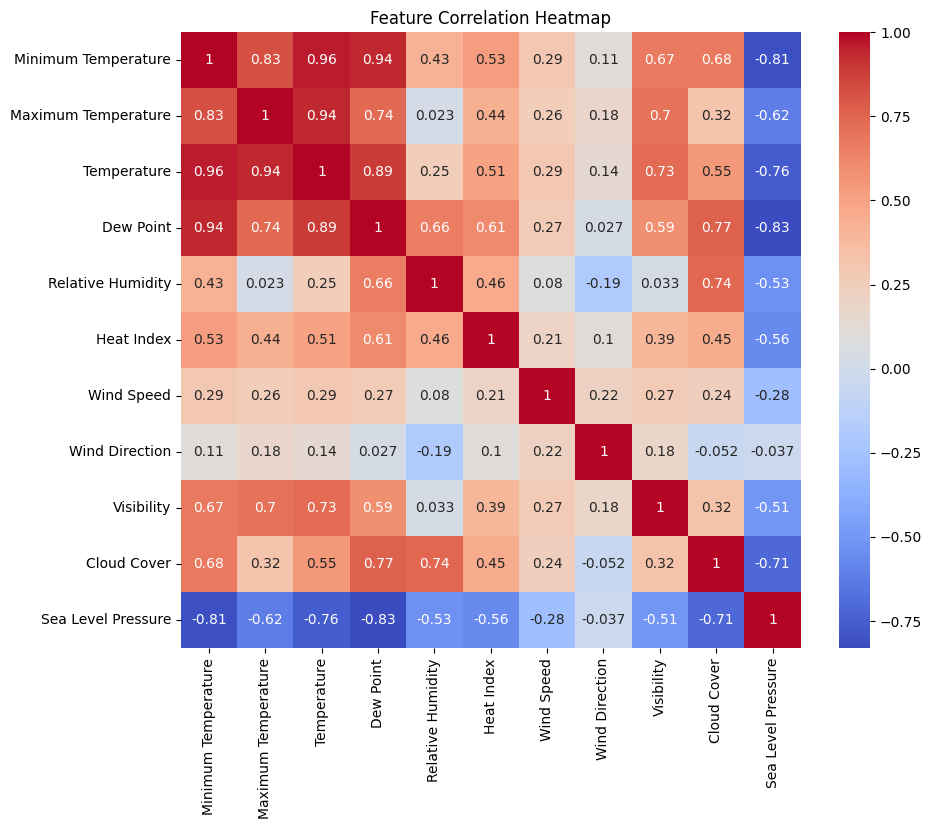

In [11]:
#Heatmap of Features
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## FEATURES DISTRIBUTION

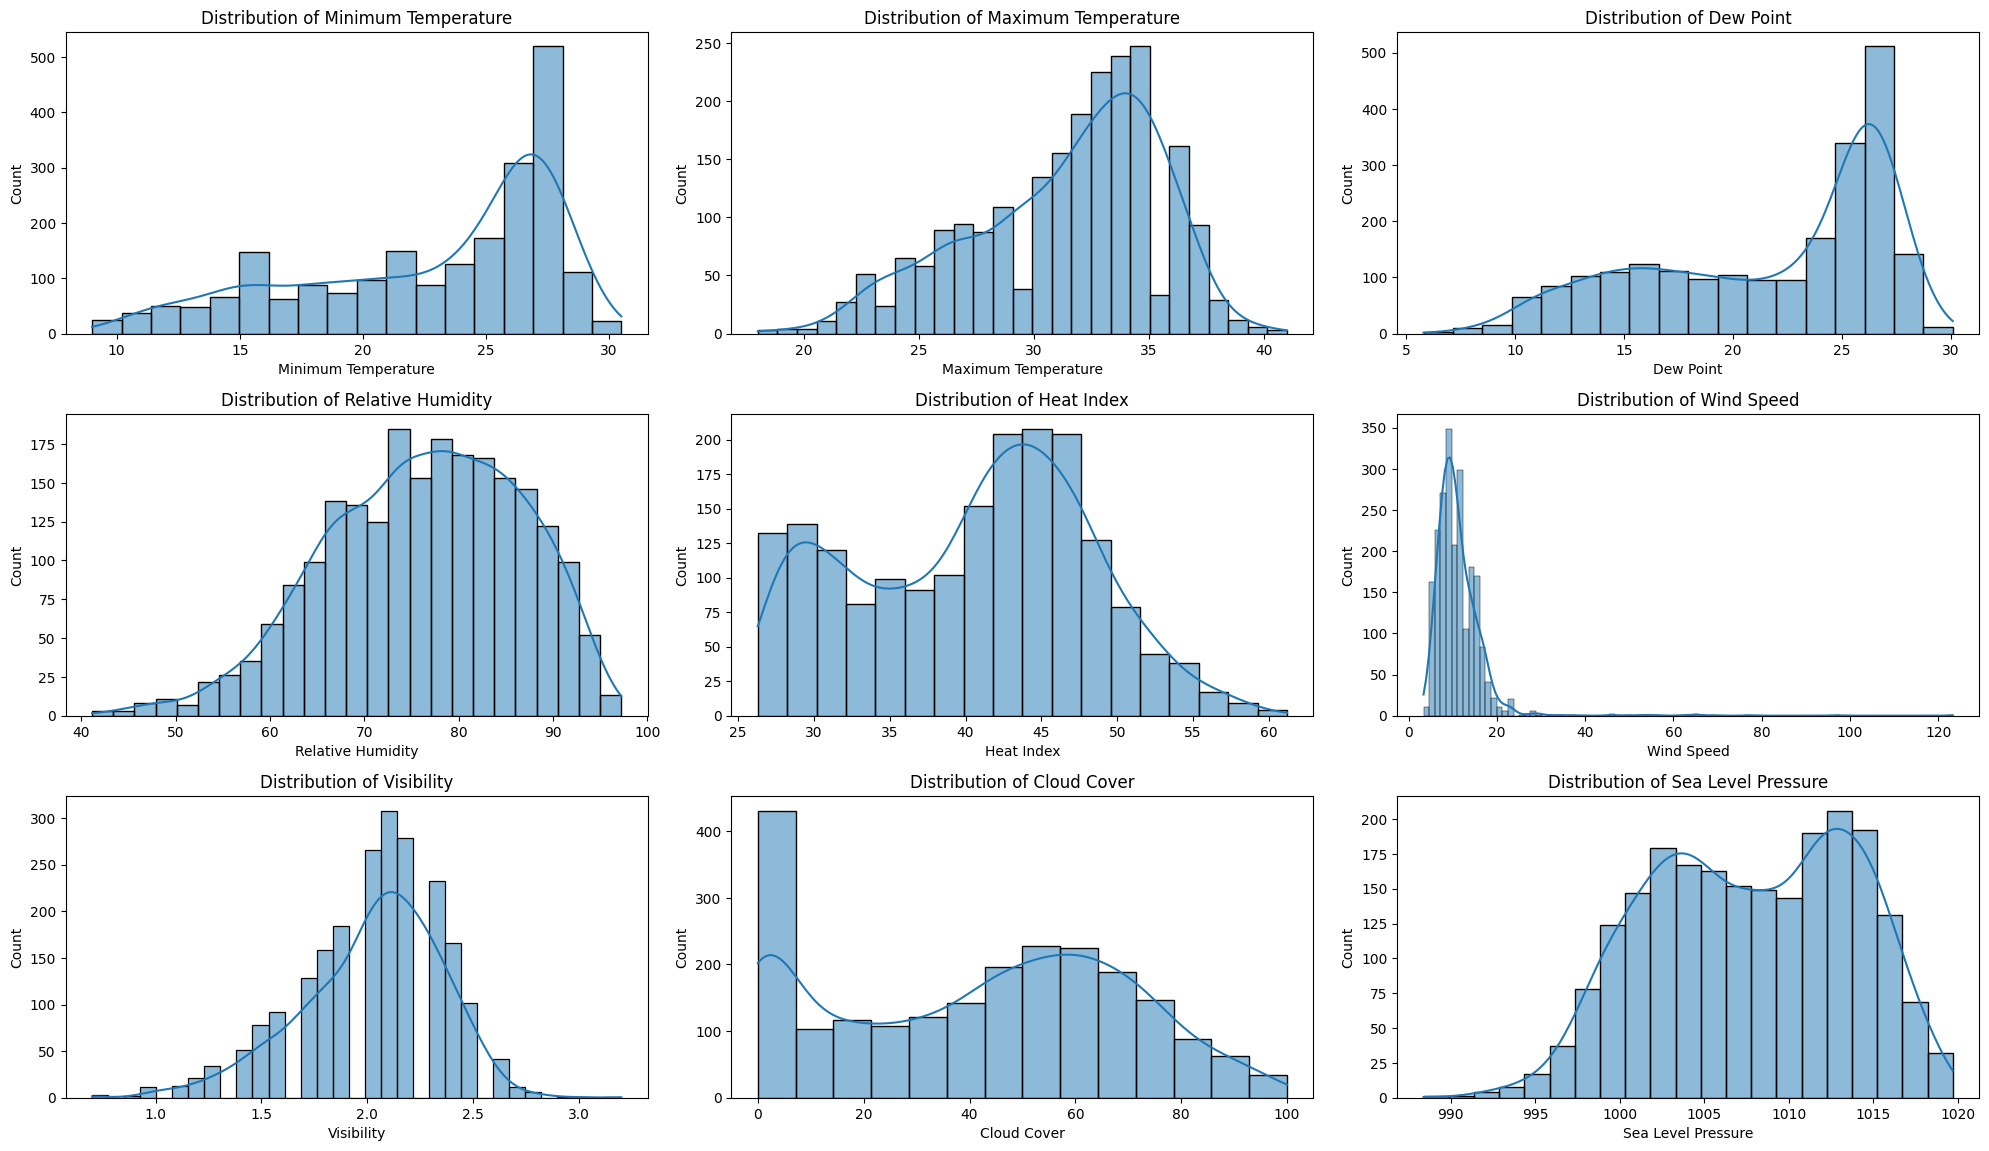

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))
feature_list = [
    'Minimum Temperature', 'Maximum Temperature', 'Dew Point', 'Relative Humidity',
    'Heat Index', 'Wind Speed', 'Visibility', 'Cloud Cover', 'Sea Level Pressure'
]

for i, column in enumerate(feature_list, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[column], kde=True)
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()


## SCALLING

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,Minimum Temperature,Maximum Temperature,Temperature,Dew Point,Relative Humidity,Heat Index,Wind Speed,Wind Direction,Visibility,Cloud Cover,Sea Level Pressure
0,-1.671210,-1.474589,-1.535063,-0.946270,0.602237,0.176284,-0.888184,-1.443789,-2.460317,-1.308706,1.367428
1,-1.288634,-1.305304,-1.376507,-1.037021,0.045032,0.176284,-0.514928,-0.104838,-1.862297,-1.473495,1.316980
2,-1.288634,-1.063469,-1.263253,-1.109622,-0.310174,-1.877803,-0.336414,1.733193,-1.264276,-1.100929,1.165636
3,-1.288634,-1.547139,-1.535063,-1.309274,-0.363845,0.176284,-0.514928,1.722895,-0.666256,-1.401848,1.148820
4,-1.479922,-1.402038,-1.603015,-1.454475,-0.431178,0.176284,-0.514928,1.478790,-0.367246,-1.484242,0.997477


## TRAIN-TEST SPLIT

In [14]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)


## LOGISTIC REGRESSION

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)
print("Logistic Regression Best Params:", grid_lr.best_params_)
print("Best F1-score (CV):", grid_lr.best_score_)


c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warni

Logistic Regression Best Params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-score (CV): 0.8325834282384326


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Train Logistic Regression
lr = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
lr.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred = lr.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87       262
           1       0.79      0.85      0.82       177

    accuracy                           0.85       439
   macro avg       0.84      0.85      0.84       439
weighted avg       0.85      0.85      0.85       439

Confusion Matrix:
 [[221  41]
 [ 26 151]]
Accuracy: 0.8473804100227791


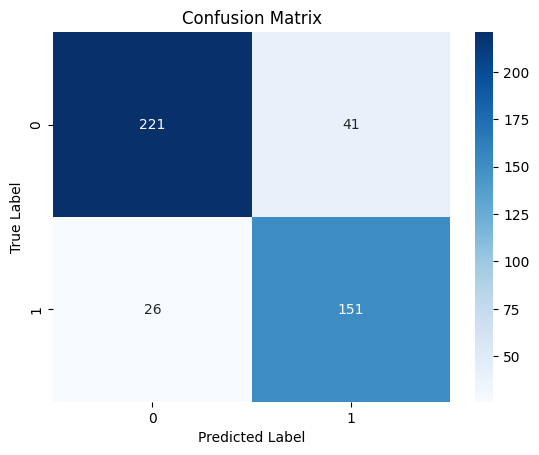

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## RANDOM FOREST CLASSIFIER

In [18]:
#Hyperparameter Tuning & cross validation for random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
print("Random Forest Best Params:", grid_rf.best_params_)
print("Best F1-score (CV):", grid_rf.best_score_)


Random Forest Best Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}
Best F1-score (CV): 0.8603031424839935


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88       262
           1       0.82      0.85      0.83       177

    accuracy                           0.86       439
   macro avg       0.85      0.86      0.86       439
weighted avg       0.86      0.86      0.86       439

Confusion Matrix:
 [[228  34]
 [ 27 150]]
Accuracy: 0.8610478359908884


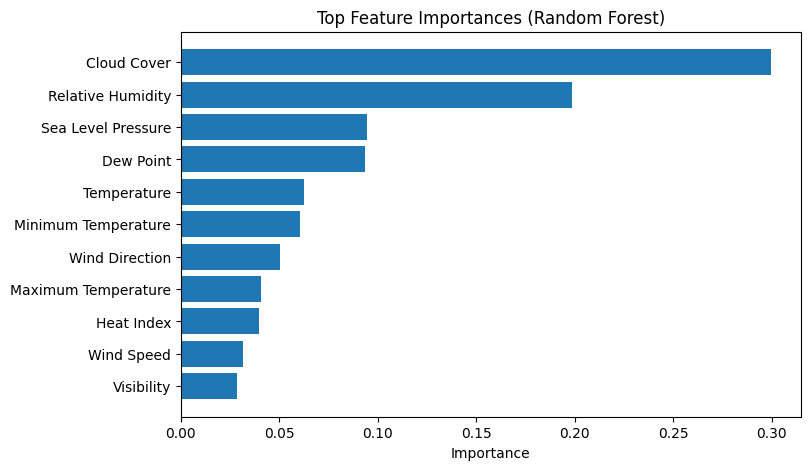

In [19]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Use balanced, scaled, and encoded data from previous steps:
# X_train_bal, y_train_bal (after SMOTE)
# X_test_scaled

# Train Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=20, random_state=42)
rf.fit(X_train_bal, y_train_bal)

# Prediction and Evaluation
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Feature Importance
import matplotlib.pyplot as plt

feature_names = X.columns
importances = rf.feature_importances_
indices = importances.argsort()[::-1][:15]             # Top 15 features
plt.figure(figsize=(8,5))
plt.title("Top Feature Importances (Random Forest)")
plt.barh([feature_names[i] for i in indices][::-1], importances[indices][::-1])
plt.xlabel("Importance")
plt.show()


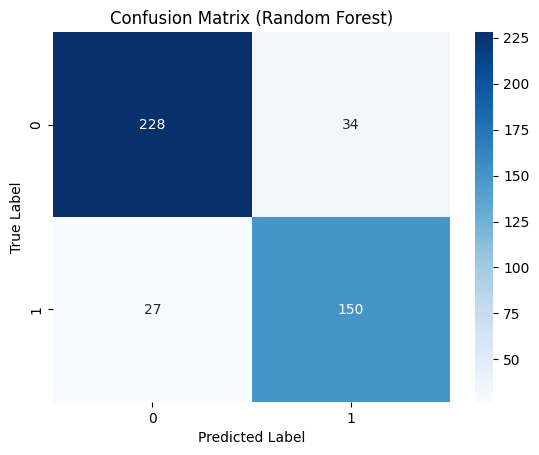

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict with random forest
y_pred_rf = rf.predict(X_test_scaled)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest)")
plt.show()


## KNN CLASSIFIER

In [21]:
#Hyperparameter Tuning & cross validation for kNN
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1')
grid_knn.fit(X_train, y_train)
print("KNN Best Params:", grid_knn.best_params_)
print("Best F1-score (CV):", grid_knn.best_score_)


KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best F1-score (CV): 0.8374153953109135


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.84      0.87       262
           1       0.79      0.85      0.82       177

    accuracy                           0.85       439
   macro avg       0.84      0.85      0.84       439
weighted avg       0.85      0.85      0.85       439

Confusion Matrix:
 [[221  41]
 [ 27 150]]
Accuracy: 0.8451025056947609


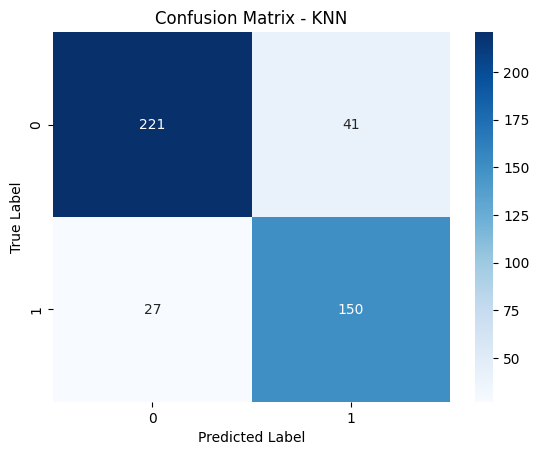

In [22]:
#KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Create and train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bal, y_train_bal)

# Predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

# Model evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

# Plot confusion matrix as heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN")
plt.show()


## DECESION TREE CLASSIFIER

In [23]:
#Hyperparameter Tuning & cross validation for Decision Tree
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=5, scoring='f1')
grid_dt.fit(X_train, y_train)
print("Decision Tree Best Params:", grid_dt.best_params_)
print("Best F1-score (CV):", grid_dt.best_score_)


Decision Tree Best Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best F1-score (CV): 0.8118955513631201


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.85       262
           1       0.76      0.82      0.79       177

    accuracy                           0.82       439
   macro avg       0.82      0.82      0.82       439
weighted avg       0.83      0.82      0.82       439

Confusion Matrix:
 [[215  47]
 [ 31 146]]
Accuracy: 0.8223234624145785


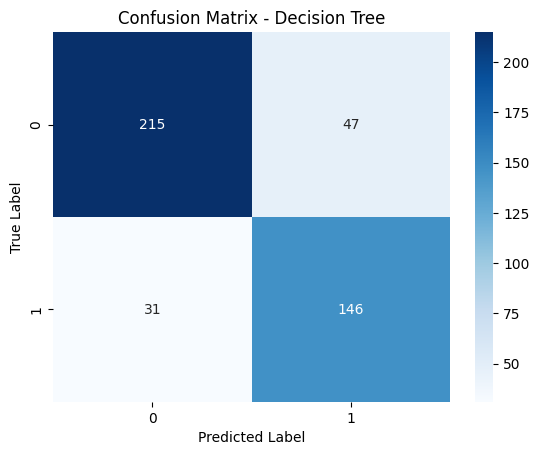

In [24]:
#Decesion Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Train the Decision Tree classifier
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train_bal, y_train_bal)

# Predict on the test set
y_pred_dt = dt.predict(X_test_scaled)

# Model evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


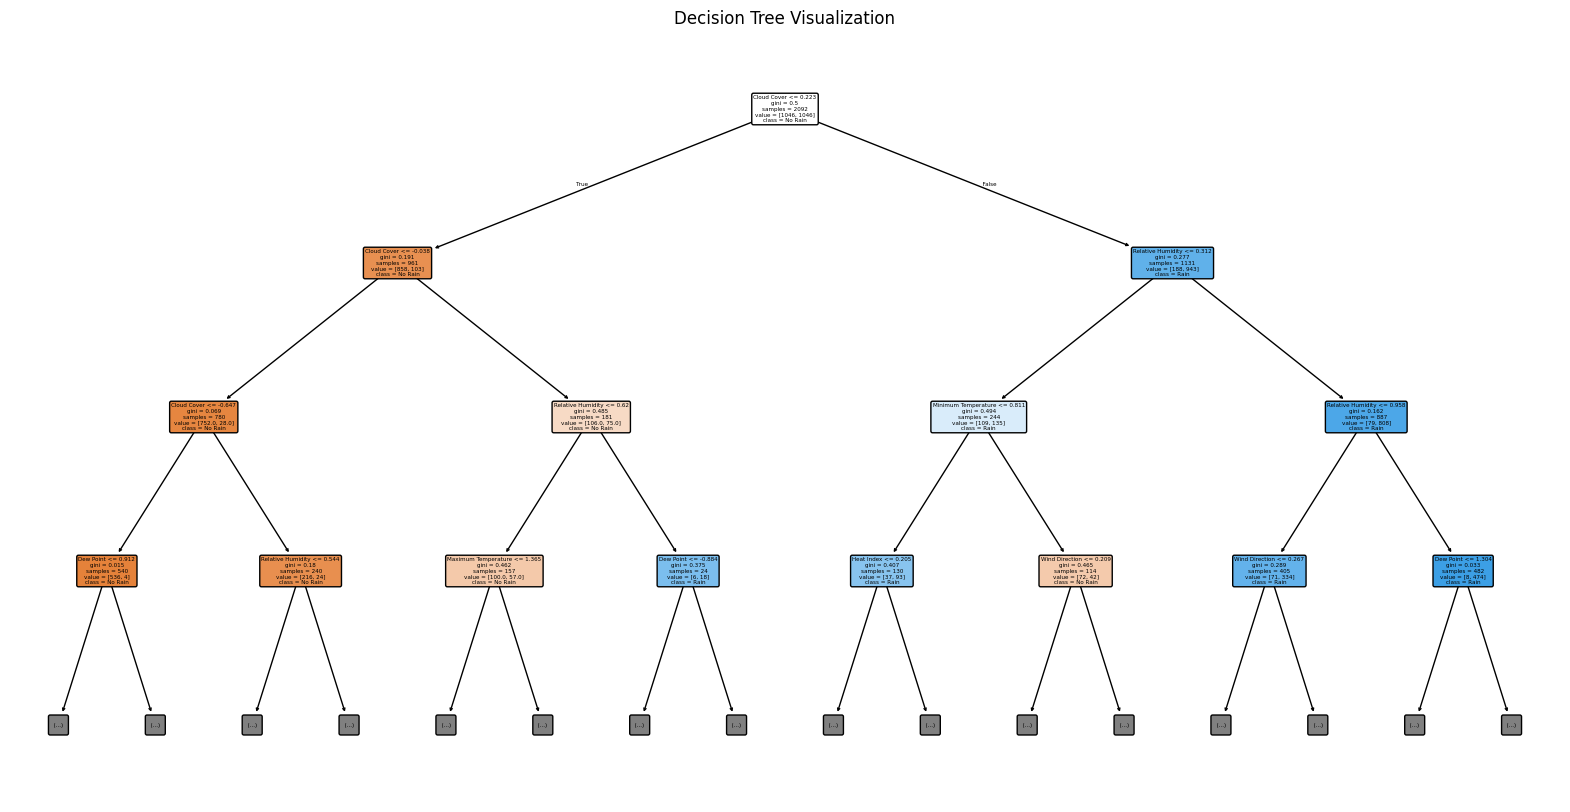

In [25]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    dt,                      
    feature_names=X.columns,             # list of feature (column) names
    class_names=["No Rain", "Rain"],      # adjust based on your label encoding
    filled=True,
    rounded=True,
    max_depth=3                         # limit depth for readability
)
plt.title("Decision Tree Visualization")
plt.show()


## TESTING MODEL

In [26]:
import pandas as pd

# Example input ( the exact feature names and order as used in training)
input_data = {
    'Minimum Temperature': 18.0,
    'Maximum Temperature': 25.0,
    'Temperature': 22.0,
    'Dew Point': 16.0,
    'Relative Humidity': 88.0,
    'Heat Index': 23.0,
    'Wind Speed': 5.0,
    'Visibility': 10.0,
    'Cloud Cover': 85.0,
    'Sea Level Pressure': 1005.0,
}
# Convert to DataFrame
test_df = pd.DataFrame([input_data])

# Make sure columns match training data and are in correct order
for col in X.columns:
    if col not in test_df.columns:
        test_df[col] = 0  
test_df = test_df[X.columns] 

# Scale using the scaler fitted on your training data
test_scaled = scaler.transform(test_df)

# Predict using your trained model
prediction = rf.predict(test_scaled)
print("Will it rain?", "Yes" if prediction[0] == 1 else "No")

# Optionally, show rain probability
print("Rain Probability:", rf.predict_proba(test_scaled)[0][1])


Will it rain? Yes
Rain Probability: 0.635


## Model Performance Comparison

The following table summarizes the test performance (Accuracy, Precision, Recall, F1-score) for all classifiers'


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr  = lr.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test_scaled)
y_pred_dt  = dt.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

# Model names and predictions
model_names = ["Logistic Regression", "Random Forest", "Decision Tree", "KNN"]
preds = [y_pred_lr, y_pred_rf, y_pred_dt, y_pred_knn]

# Single table for comparison
results = []
for name, y_pred in zip(model_names, preds):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.847380   0.786458  0.853107  0.818428
1        Random Forest  0.861048   0.815217  0.847458  0.831025
2        Decision Tree  0.822323   0.756477  0.824859  0.789189
3                  KNN  0.845103   0.785340  0.847458  0.815217


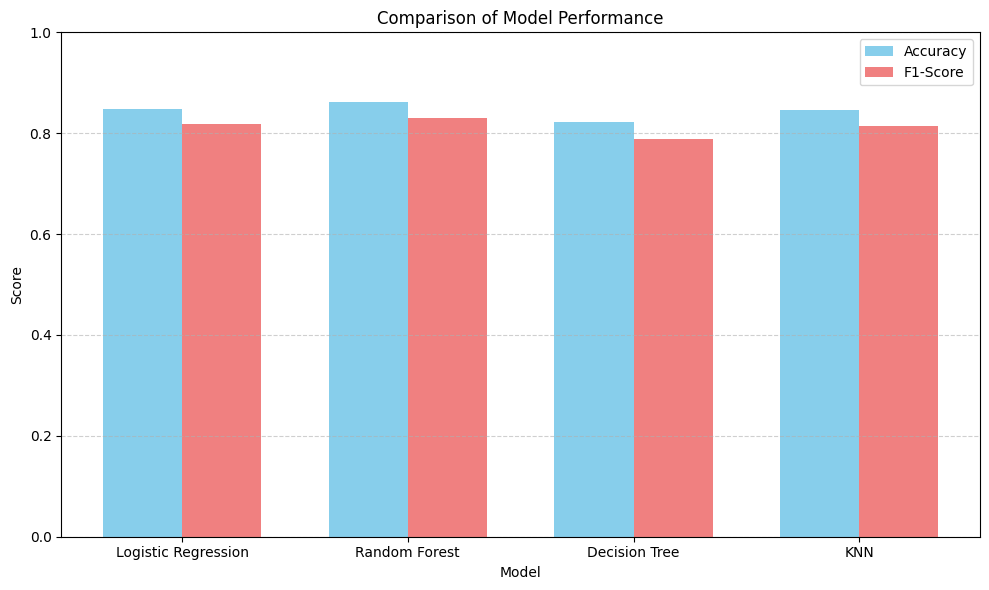

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Fill these lists with own metric scores
models = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN']
accuracies = [accuracy_score(y_test, y_pred_lr),
              accuracy_score(y_test, y_pred_rf),
              accuracy_score(y_test, y_pred_dt),
              accuracy_score(y_test, y_pred_knn)]
f1_scores = [f1_score(y_test, y_pred_lr),
             f1_score(y_test, y_pred_rf),
             f1_score(y_test, y_pred_dt),
             f1_score(y_test, y_pred_knn)]

x = np.arange(len(models))  # [0, 1, 2, 3]

plt.figure(figsize=(10, 6))
bar_width = 0.35

plt.bar(x, accuracies, width=bar_width, color='skyblue', label='Accuracy')
plt.bar(x + bar_width, f1_scores, width=bar_width, color='lightcoral', label='F1-Score')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Model Performance')
plt.xticks(x + bar_width / 2, models)
plt.legend()
plt.ylim([0,1])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
